# Kappa for group vs. individual parcellations  

This notebook summarizes the results of looking at the impact on the choice of kappa on the balance of the data-only and prior only parcellation.

In [2]:
# Add the directories of necessary packages to the Python path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## DCBC for MDTB dataset - training on S1 and evaluating on S2. 

* V is estimated from all 16 runs 
* The individual parcellation is done on 16,8, or 2 runs. 
* We vary kappa from 0 (group only) to 200 (practically data only)  

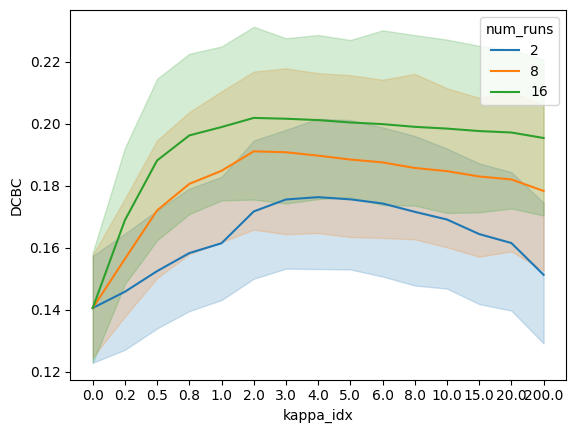

In [8]:
T1 = pd.read_csv('../results/kappa_individ_runs-02_train-s1.tsv', sep='\t')
T2 = pd.read_csv('../results/kappa_individ_runs-08_train-s1.tsv', sep='\t')
T3 = pd.read_csv('../results/kappa_individ_runs-16_train-s1.tsv', sep='\t')
T = pd.concat([T1, T2, T3])
T['num_runs'] = T['num_runs'].astype(str)
k,T['kappa_idx']=np.unique(T.kappa,return_inverse=True)
sns.lineplot(data=T, x='kappa_idx', y='DCBC',hue='num_runs')
# Set the x-tick labels
a= plt.xticks(range(len(k)), k)

<Axes: xlabel='num_runs', ylabel='kappa_indiv'>

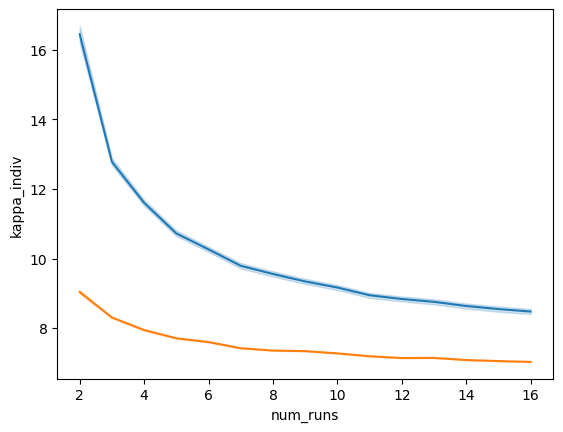

In [9]:
E = pd.read_csv('../results/kappa_individ_estimation_s1.tsv', sep='\t')
sns.lineplot(data=E, x='num_runs', y='kappa_indiv')
sns.lineplot(data=E, x='num_runs', y='kappa_group')
# Set the x-tick labels


<Axes: xlabel='num_runs', ylabel='kappa_indiv'>

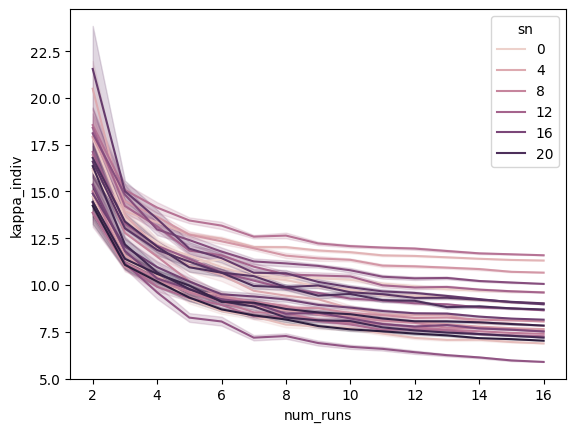

In [10]:
sns.lineplot(data=E, x='num_runs', y='kappa_indiv',hue='sn')

Text(0, 0.5, 'Best Kappa (on SC2)')

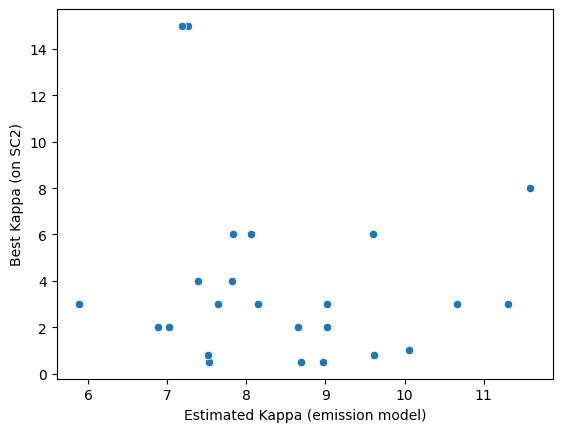

In [12]:
dcbc = pd.pivot_table(T3, values='DCBC', index='sn', columns='kappa')
best = dcbc.to_numpy().argmax(axis=1)
best_kappa = k[best]
best_kappa[best_kappa==200] = 15
kappa_est = pd.pivot_table(E[E.num_runs==16],values='kappa_indiv',index='sn',columns=[]).to_numpy().flatten()
sns.scatterplot(y=best_kappa,x=kappa_est)
plt.xlabel('Estimated Kappa (emission model)')
plt.ylabel('Best Kappa (on SC2)')

## Simulations
Is this problem due to some mis-estimation of kappa?  

<Axes: xlabel='num_runs', ylabel='kappa_indiv'>

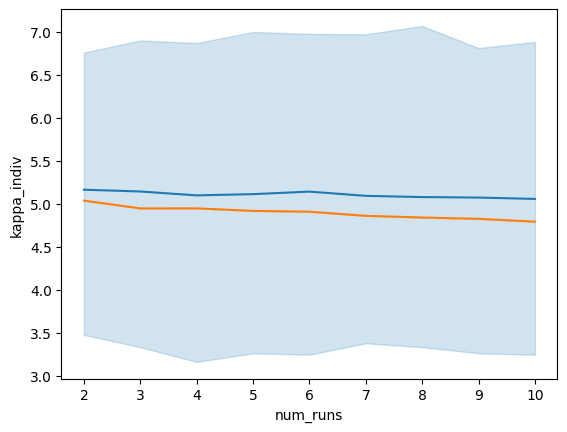

In [13]:
S = pd.read_csv('../results/kappa_individ_simulation.tsv', sep='\t')

sns.lineplot(data=S, x='num_runs', y='kappa_indiv')
sns.lineplot(data=S, x='num_runs', y='kappa_group')



<Axes: xlabel='kappa_true', ylabel='kappa_indiv'>

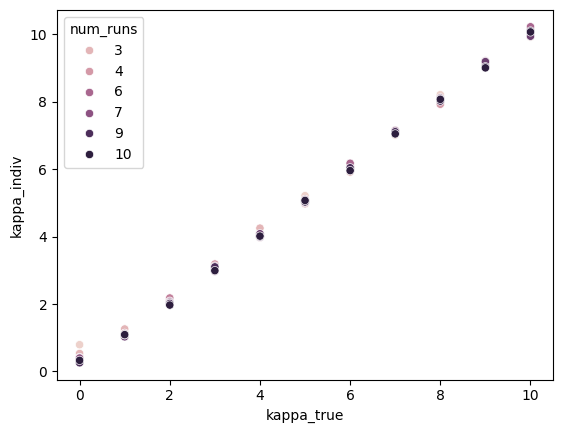

In [14]:
sns.scatterplot(data=S, x='kappa_true', y='kappa_indiv',hue='num_runs')

<Axes: xlabel='kappa_true', ylabel='kappa_indiv'>

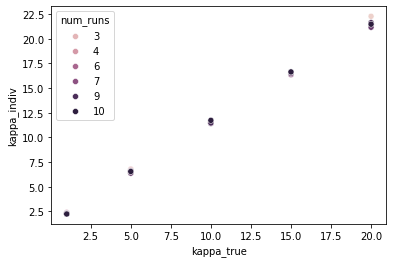

In [3]:
S = pd.read_csv('../results/kappa_individ_simulation2.tsv', sep='\t')

sns.scatterplot(data=S, x='kappa_true', y='kappa_indiv',hue='num_runs')